In [5]:
import pandas as pd
import numpy as np
df = pd.read_csv("C:/Users/HP/OneDrive/Desktop/python/njjnjbjj/data.csv", encoding="latin1")
print(df.head())

print(df.head())
print(df.shape)
print(df.info)
print(df.isnull().sum())
print(df.describe())
df_with_customer= df.dropna(subset = [ "CustomerID"]).copy()
df_with_customer["CustomerID"] = df_with_customer["CustomerID"].astype(int)
df_with_customer["CustomerID"]

df_with_customer["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").sum()

df_with_customer["IsCancelled"] = df_with_customer["InvoiceNo"].astype(str).str.startswith("C")

df_clean = df_with_customer[
    (~df_with_customer["IsCancelled"]) &
    (df_with_customer["Quantity"] > 0) &
    (df_with_customer["UnitPrice"] > 0)].copy()

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], format="%m/%d/%Y %H:%M")
df_clean["TotalPrice"] = np.multiply(df_clean["Quantity"], df_clean["UnitPrice"])
print(df_clean["TotalPrice"].head())





print("\n")

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6 

In [6]:
print( " STEP : 3 Data Cleaned")
print("Original rows : " , df.shape[0], " Clean Rows " , df_clean.shape[0])
print("Cancelled orders removed:", df_with_customer["IsCancelled"].sum())
print(df_clean[["InvoiceNo", "Quantity", "UnitPrice", "TotalPrice", "InvoiceDate"]].head())

 STEP : 3 Data Cleaned
Original rows :  541909  Clean Rows  397884
Cancelled orders removed: 8905
  InvoiceNo  Quantity  UnitPrice  TotalPrice         InvoiceDate
0    536365         6       2.55       15.30 2010-12-01 08:26:00
1    536365         6       3.39       20.34 2010-12-01 08:26:00
2    536365         8       2.75       22.00 2010-12-01 08:26:00
3    536365         6       3.39       20.34 2010-12-01 08:26:00
4    536365         6       3.39       20.34 2010-12-01 08:26:00


In [8]:
#Extract the year from the "InvoiceDate" column and store it in a new column year

df_clean["Year"] = df_clean["InvoiceDate"].dt.year
#extract month (1-12) from the "invoicedate" column
df_clean["Month"] =  df_clean["InvoiceDate"].dt.month
#extract day (1-31) from the "invoicedate" column

df_clean["Day"] =  df_clean["InvoiceDate"].dt.day
#extract the hour(0 -24) from the "invoicedate" column
df_clean["hour"] = df_clean["InvoiceDate"].dt.hour
#extract the name of the day of the week
df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()
print( " Step 4  : Date features added")
print(df_clean[["InvoiceDate", "Year", "Month", "DayOfWeek", "hour"]].head(10)) 
print("\n")

 Step 4  : Date features added
          InvoiceDate  Year  Month  DayOfWeek  hour
0 2010-12-01 08:26:00  2010     12  Wednesday     8
1 2010-12-01 08:26:00  2010     12  Wednesday     8
2 2010-12-01 08:26:00  2010     12  Wednesday     8
3 2010-12-01 08:26:00  2010     12  Wednesday     8
4 2010-12-01 08:26:00  2010     12  Wednesday     8
5 2010-12-01 08:26:00  2010     12  Wednesday     8
6 2010-12-01 08:26:00  2010     12  Wednesday     8
7 2010-12-01 08:28:00  2010     12  Wednesday     8
8 2010-12-01 08:28:00  2010     12  Wednesday     8
9 2010-12-01 08:34:00  2010     12  Wednesday     8




In [10]:
#calculate the total revenue generated from all valid transaction
#np.sum() adds all values in the "totalprice" column
#formula: total revenue = sum of all totalprice values

total_revenue = df_clean["TotalPrice"].sum()

#calculate the total number of unique orders (invoices)
#nunique() counts unique invoiceNo values
#if an invoice contains.multiple products , it is still counted as one order
total_orders = df_clean["InvoiceNo"].nunique()

#calculate the total number of unique customers
#nunique() counts distinct CustomerID values
# if a customer places multiple orders, they are counted only once
total_customers = df_clean["CustomerID"].nunique()

#calculate the average order value(AOV)
#Step1 : Group all rows by InvoiceNo (each invoice may contain multiple products)
#step2 :  sum the totalPrice of all products within each invoice
#step3 : calculate the average of all invoice totals
avg_order_value = df_clean.groupby("InvoiceNo")["TotalPrice"].sum().mean()
#Display the result
# Display the result

print("STEP 5: Key Metrics")
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Unique Orders: {total_orders}")
print(f"Total Unique Customers: {total_customers}")
print(f"Average Order Value: £{avg_order_value:,.2f}")
print("\n")

STEP 5: Key Metrics
Total Revenue: £8,911,407.90
Total Unique Orders: 18532
Total Unique Customers: 4338
Average Order Value: £480.87




In [11]:
#step 6:
#Find the top 10 products that generated the highest total revenue

top_products_revenue = (df_clean.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10))
#Find the top 10 products sold in the highest quantities

top_products_qty  = ( df_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10))

#display the result
print("top 10 products that generated the highest total revenue\n")
print(top_products_revenue)
print("top 10 products sold in the highest quantities\n")
print(top_products_qty)

top 10 products that generated the highest total revenue

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: TotalPrice, dtype: float64
top 10 products sold in the highest quantities

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBI

In [12]:
#Step 7 :country wise analysis

#calculate the total revenue generated by each country and sort it from highest to lowest
country_revenue =  ( df_clean.groupby("Country")["TotalPrice"].sum().astype(int).sort_values(ascending = False))
#display the result
print("STEP 7 : Revenue by country ( top 10 )")
print(country_revenue.head(10))
print("\n")

STEP 7 : Revenue by country ( top 10 )
Country
United Kingdom    7308391
Netherlands        285446
EIRE               265545
Germany            228867
France             209024
Australia          138521
Spain               61577
Switzerland         56443
Belgium             41196
Sweden              38378
Name: TotalPrice, dtype: int64




In [13]:
#step 8: Monthly sales trend
#create a new column containing only the year and month form the invoiceDate
df_clean[ "YearMonth"] = df_clean[ "InvoiceDate"].dt.to_period("M")
#calcualte the total sales (revenue) for each year month
monthly_sales = df_clean.groupby("YearMonth")[ "TotalPrice"].sum().head(5)
df_clean["MonthDay"] = df_clean[ "InvoiceDate"].dt.to_period("D")
#calcualte the total sales (revenue) for each month

day_sales = df_clean.groupby("MonthDay")["TotalPrice"].sum().head(5)
df_clean["DayHours"] = df_clean[ "InvoiceDate"].dt.to_period("h")
#for hour
hour_sales = df_clean.groupby("DayHours")["TotalPrice"].sum().head(5)


#displaying the result

print( "Step  8 : \nMonthly revenue trend")
print(monthly_sales)
print("Day sales\n")
print(day_sales)
print(" day hour sales \n")
print(hour_sales)
print("\n")

Step  8 : 
Monthly revenue trend
YearMonth
2010-12    572713.890
2011-01    569445.040
2011-02    447137.350
2011-03    595500.760
2011-04    469200.361
Freq: M, Name: TotalPrice, dtype: float64
Day sales

MonthDay
2010-12-01    46376.49
2010-12-02    47316.53
2010-12-03    23921.71
2010-12-05    31771.60
2010-12-06    31215.64
Freq: D, Name: TotalPrice, dtype: float64
 day hour sales 

DayHours
2010-12-01 08:00    1383.81
2010-12-01 09:00    7356.39
2010-12-01 10:00    5235.81
2010-12-01 11:00    4234.16
2010-12-01 12:00    7447.92
Freq: h, Name: TotalPrice, dtype: float64




In [14]:
#step 9 : customer analysis (RFM style basics)
#create a customer summary by calculating spending, orders, average order value, and last purchase date and 
# then sort customers by highest total spending
customer_summary = df_clean.groupby("CustomerID").agg(
    TotalSpend=("TotalPrice", "sum"),
    numOrders=("InvoiceNo", "nunique"),
    AvgOrderValue=("TotalPrice", "mean"),
    LastPurchase=("InvoiceDate", "max")
).sort_values("TotalSpend", ascending=False)

#Show the result

print("Step 9 : TOP 10 Customers by total spend\n")
print(customer_summary.head(5))

Step 9 : TOP 10 Customers by total spend

            TotalSpend  numOrders  AvgOrderValue        LastPurchase
CustomerID                                                          
14646        280206.02         73     134.973998 2011-12-08 12:12:00
18102        259657.30         60     602.453132 2011-12-09 11:50:00
17450        194550.79         46     577.302047 2011-12-01 13:29:00
16446        168472.50          2   56157.500000 2011-12-09 09:15:00
14911        143825.06        201      25.343623 2011-12-08 15:54:00


In [15]:
#step 10: Numpy-base statistical analysis on order values

#calculate the total value of each order (invoice) and store the results as a numPY array

order_values = df_clean.groupby("InvoiceNo")["TotalPrice"].sum().values
order_values

#step 10 : calculate and display basic statistics for order values

print( " STEP 10 : order value statistics (Numpy)")
#display the average order
print(" mean :" , np.mean(order_values))
#display the middle order value
print(" Median :" , np.median(order_values))
#display the spread of order values
print(" Standard Deviation :" , np.std(order_values))
#display the smallest order value
print(" Minimum :" , np.min(order_values))
#display the largest order value
print(" Maximum :" , np.max(order_values))
#display the value below which 25% of worders fall
print(" 25th percentile :" , np.percentile(order_values, 25))
#display the value below which 75% of worders fall
print(" 75th percentile :" , np.percentile(order_values, 75))

 STEP 10 : order value statistics (Numpy)
 mean : 480.8659563997409
 Median : 303.03999999999996
 Standard Deviation : 1678.1503005606626
 Minimum : 0.38
 Maximum : 168469.6
 25th percentile : 158.0375
 75th percentile : 471.84000000000003


In [16]:
#step 11 : save cleaned data & summary outputs

# save the cleaned dataset to a csv file without including the row index

df_clean.to_csv( "cleaned_ecommerce_data.csv" , index = False)
#save the customer summary report to a csv file

customer_summary.to_csv("customer_summary.csv")
#save the country wise revenue to a csv file

country_revenue.to_csv("country_revenue.csv")


print("STEP 11: Files saved -> cleaned_ecommerce_data.csv, customer_summary.csv, country_revenue.csv")

STEP 11: Files saved -> cleaned_ecommerce_data.csv, customer_summary.csv, country_revenue.csv


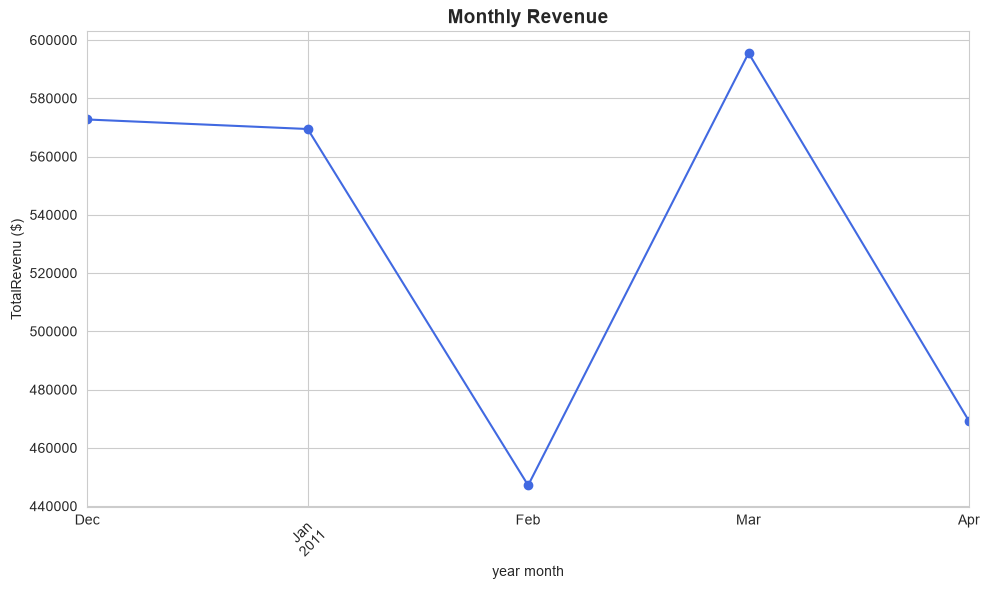

In [18]:
#step 12: Data Visualization ( Matplotlib + seaborn)
#using seaborn to get overall theme
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

#----------------------
#1. Monthly Sales trend (line chart)
#----------------------
plt.figure()
monthly_sales.plot(kind="line", marker="o", color="royalblue")
plt.title("Monthly Revenue" , fontsize = 14, fontweight = "bold")
plt.xlabel("year month")
plt.ylabel("TotalRevenu ($)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

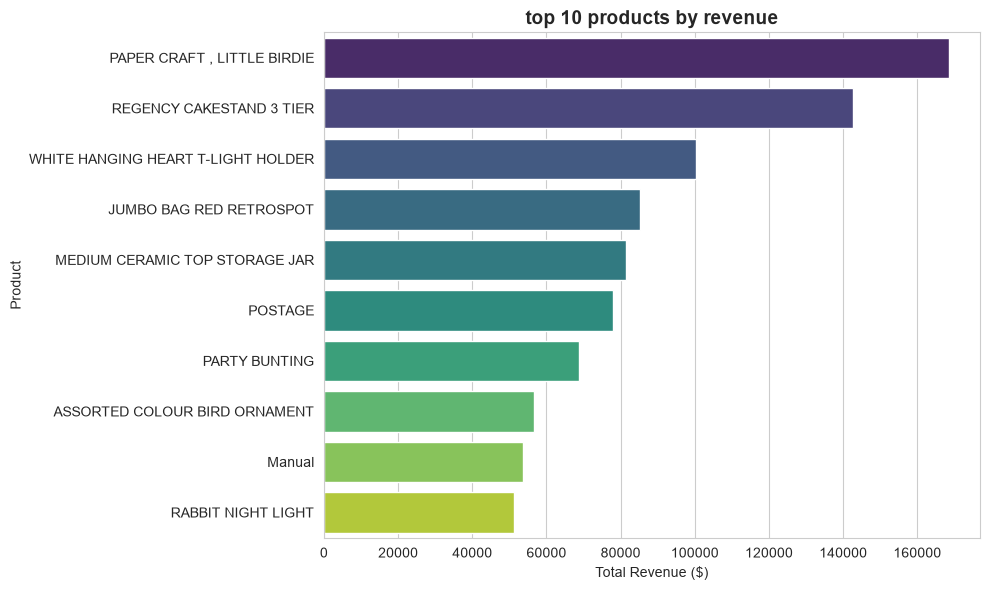

In [19]:
#Top 10 products by revenue (Bar Chart)
plt.figure(figsize=(10,6))
sns.barplot(
    x = top_products_revenue.values,
    y = top_products_revenue.index,
    hue = top_products_revenue.index,
    palette = "viridis",
    legend=False
)
plt.title("top 10 products by revenue", fontsize = 14, fontweight = "bold")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("top_products_revenue.png", dpi = 150)
plt.show()

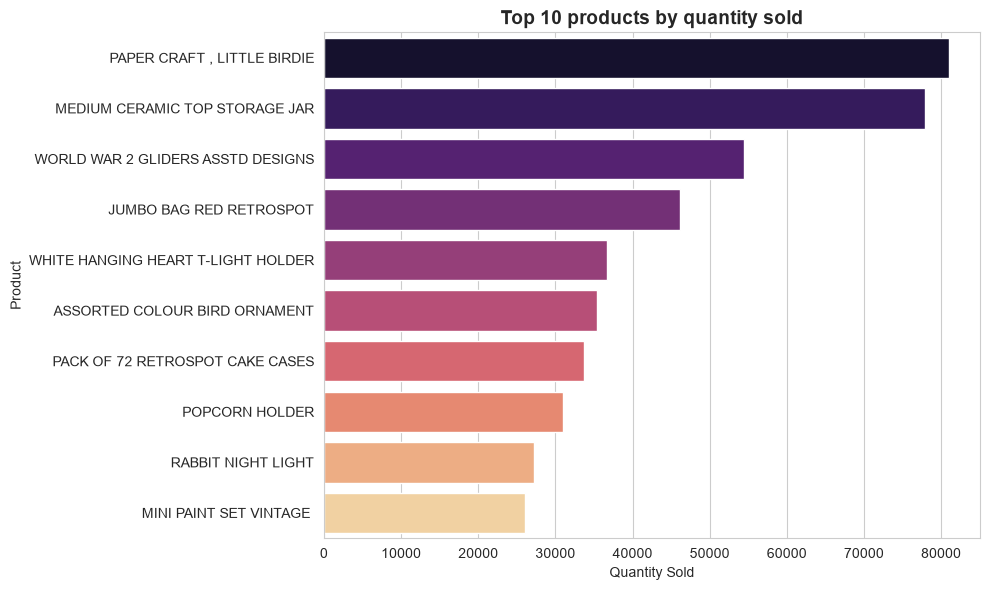

In [20]:
#top 10 product by quantity sold( Bar Chart)
#-----------------------------------------------
plt.figure()
sns.barplot(
    x = top_products_qty.values, 
    y = top_products_qty.index, 
    hue = top_products_qty.index,
    palette= "magma"
)
plt.title("Top 10 products by quantity sold", fontsize = 14, fontweight = "bold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("top_products_quantity.png", dpi=150, bbox_inches="tight")
plt.show()

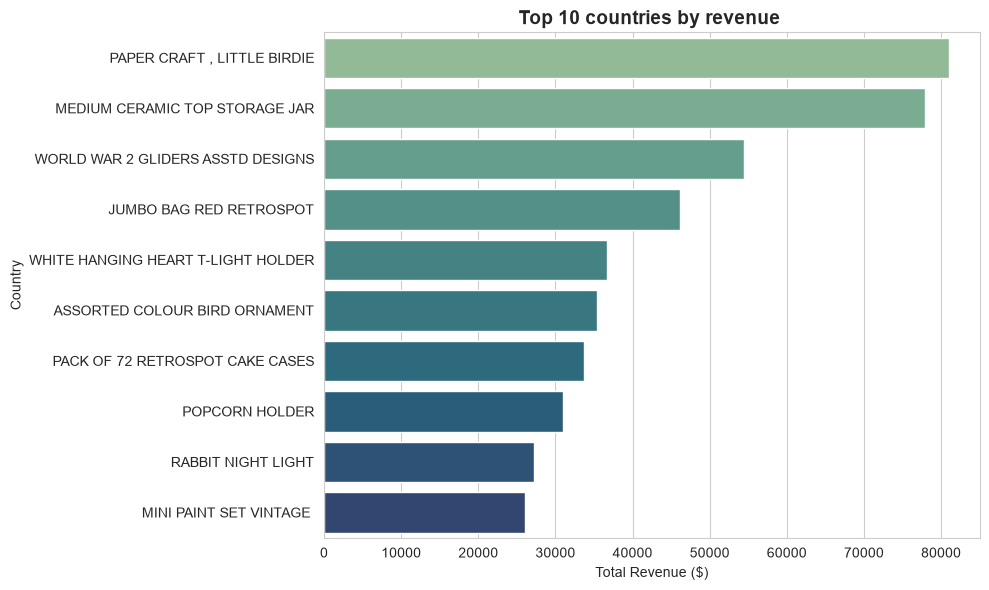

In [21]:
# 4. Revenue by Top 10 countries
plt.figure()
sns.barplot(
    x = top_products_qty.values, 
    y = top_products_qty.index, 
    hue = top_products_qty.index,
    palette= "crest"
)
plt.title("Top 10 countries by revenue ", fontsize = 14, fontweight = "bold")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("Revenue_by_country.png", dpi=150)
plt.show()

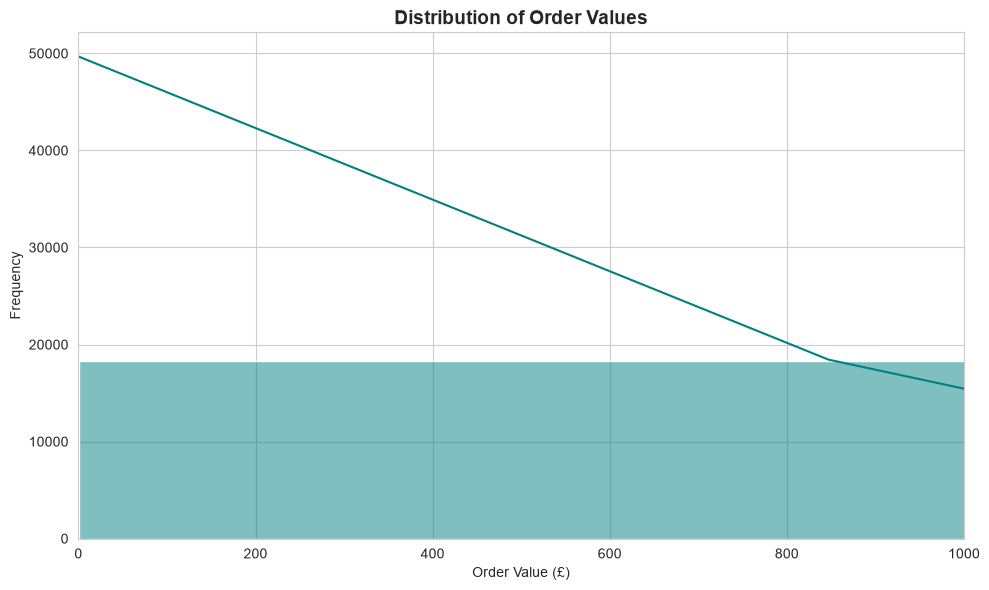

In [22]:
#5.Distribution of Order Values (Histogram + KDE)
# ---------------------------------------------------------
plt.figure()
sns.histplot(order_values, bins=50, kde=True, color="teal")
plt.title("Distribution of Order Values", fontsize=14, fontweight="bold")
plt.xlabel("Order Value (£)")
plt.ylabel("Frequency")
plt.xlim(0, 1000)  
plt.tight_layout()
plt.savefig("order_value_distribution.png", dpi=150)
plt.show()

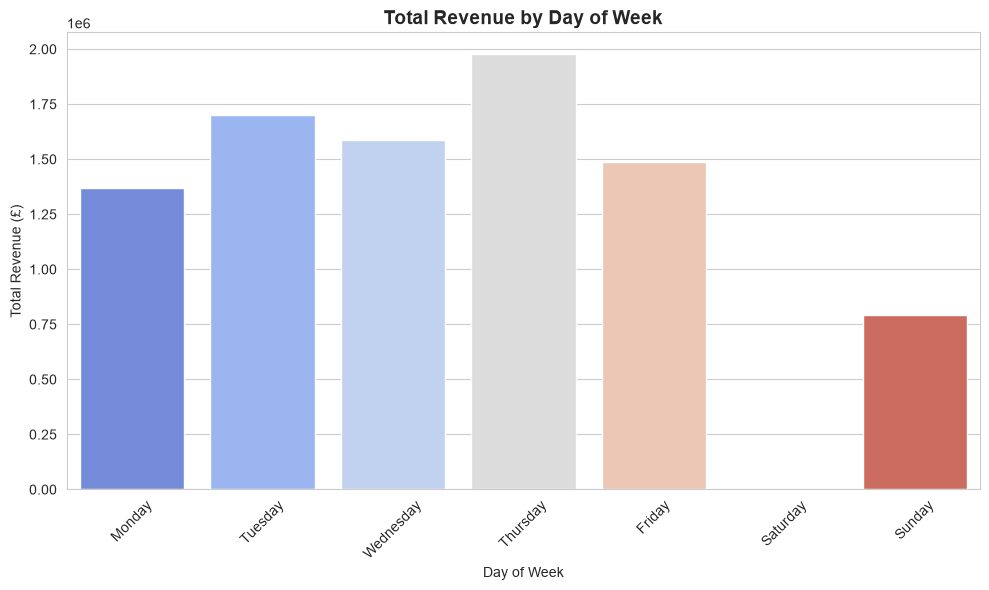

In [23]:
# 6. Sales by Day of Week (Bar Chart)
# ---------------------------------------------------------
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]
sales_by_day = (
    df_clean.groupby("DayOfWeek")["TotalPrice"]
    .sum()
    .reindex(day_order)
)
 
plt.figure()
sns.barplot(
    x=sales_by_day.index,
    y=sales_by_day.values,
    hue=sales_by_day.index,
    palette="coolwarm"
)
plt.title("Total Revenue by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_by_dayofweek.png", dpi=150)
plt.show()

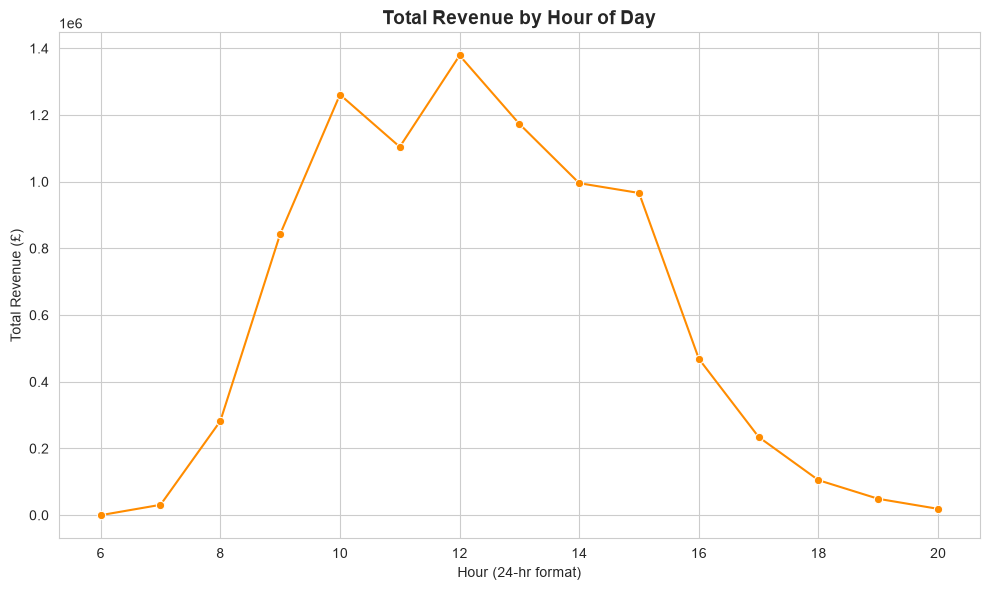

In [25]:
# 7. Sales by Hour of Day (Line Chart)
# ---------------------------------------------------------
sales_by_hour = df_clean.groupby("hour")["TotalPrice"].sum()
 
plt.figure()
sns.lineplot(x=sales_by_hour.index, y=sales_by_hour.values,
             marker="o", color="darkorange")
plt.title("Total Revenue by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour (24-hr format)")
plt.ylabel("Total Revenue (£)")
plt.tight_layout()
plt.savefig("sales_by_hour.png", dpi=150)
plt.show()

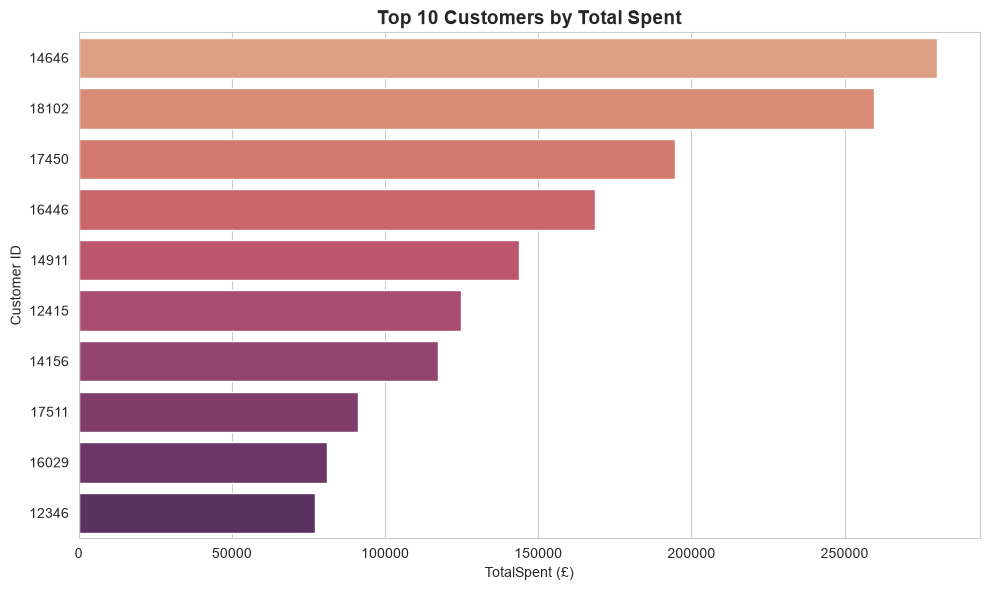

In [30]:
# 8. Top 10 Customers by Total Spend (Bar Chart)
# ---------------------------------------------------------
top_customers = customer_summary.head(10)
 
plt.figure()
sns.barplot(
    x=top_customers["TotalSpend"].values,
    y=top_customers.index.astype(str),
    hue=top_customers.index.astype(str),
    palette="flare"
)
plt.title("Top 10 Customers by Total Spent", fontsize=14, fontweight="bold")
plt.xlabel("TotalSpent (£)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig("top_customers.png", dpi=150)
plt.show()

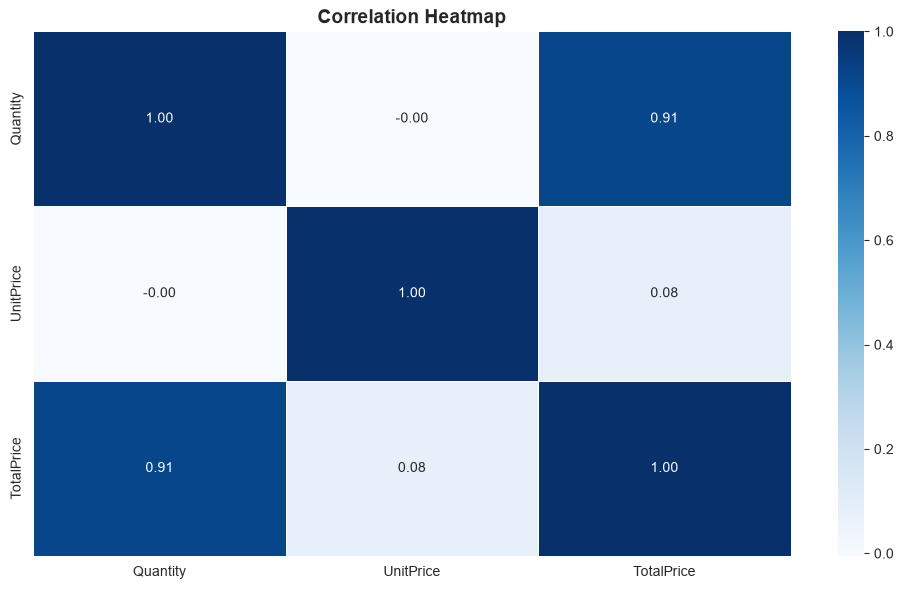

STEP 12: All visualizations created and saved as PNG files.


In [31]:
#9. Correlation Heatmap (Quantity, UnitPrice, TotalPrice)
# ---------------------------------------------------------
plt.figure()
corr = df_clean[["Quantity", "UnitPrice", "TotalPrice"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
 
print("STEP 12: All visualizations created and saved as PNG files.")

In [33]:
data = {'Name': ['Amit', 'Rahul', 'Kumar'], 'Salary': [1000, 2000, 3000]}
df=pd.DataFrame(data,index=['a','b','c'])
print(df)

    Name  Salary
a   Amit    1000
b  Rahul    2000
c  Kumar    3000


In [34]:
obj_data=df.reindex(['c','b','a'])
print(obj_data)

    Name  Salary
c  Kumar    3000
b  Rahul    2000
a   Amit    1000
